In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print('Dataset Loaded!')
print(f'Training images : {x_train.shape}')
print(f'Testing images  : {x_test.shape}')

Dataset Loaded!
Training images : (50000, 32, 32, 3)
Testing images  : (10000, 32, 32, 3)


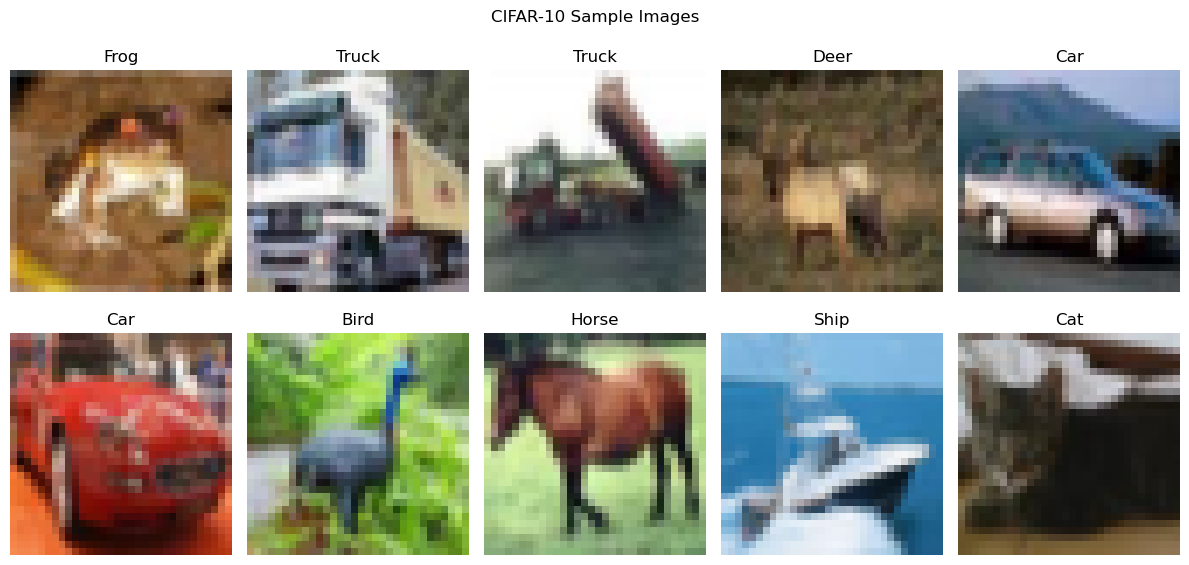

In [2]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle('CIFAR-10 Sample Images')
plt.tight_layout()
plt.show()

In [3]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0

model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),
    
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [1]:
print('Training started...')

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_data=(x_test, y_test))

print('Training Complete!')

Training started...


NameError: name 'model' is not defined

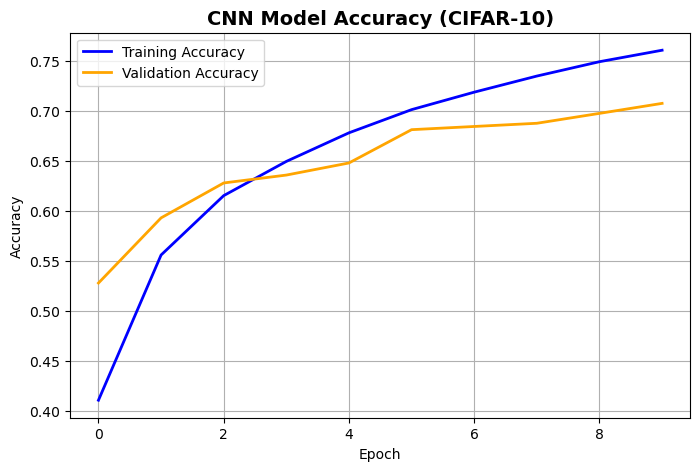

Final Validation Accuracy: 70.80%


In [5]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('CNN Model Accuracy (CIFAR-10)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

final_acc = history.history['val_accuracy'][-1] * 100
print(f'Final Validation Accuracy: {final_acc:.2f}%')

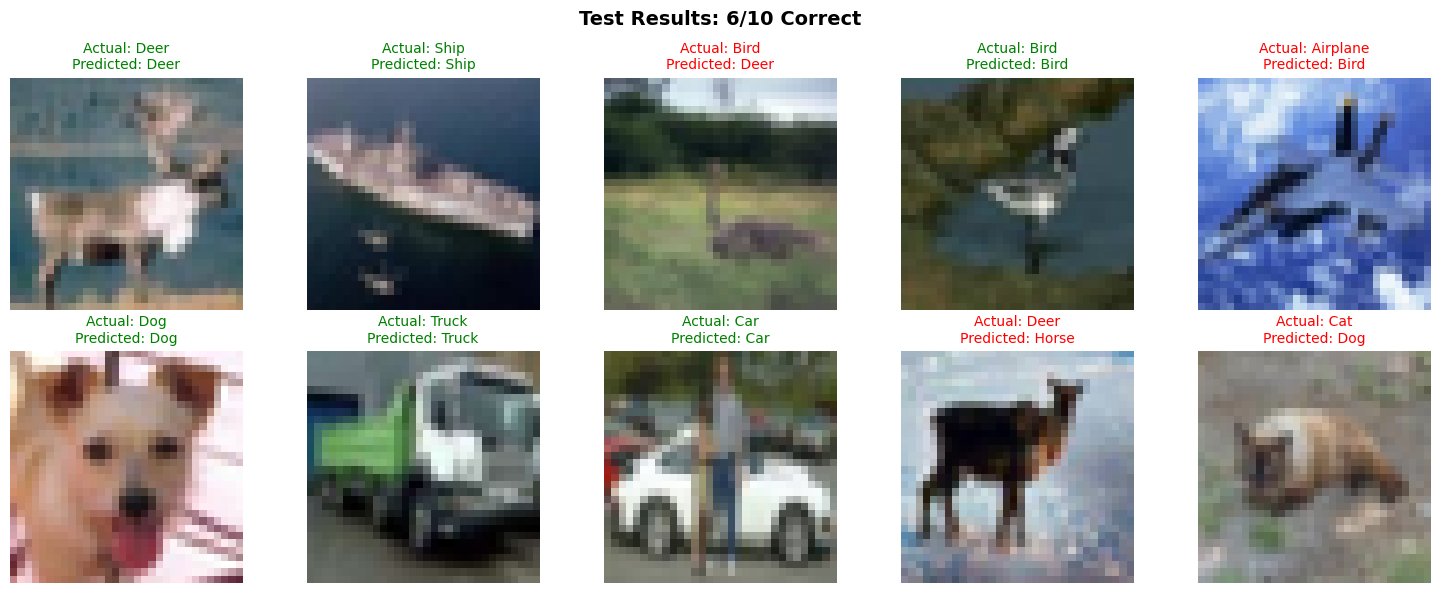

In [6]:
plt.figure(figsize=(15, 6))
correct = 0

for i in range(10):
    idx = np.random.randint(0, len(x_test))
    img = x_test[idx]
    actual = y_test[idx][0]
    predicted = np.argmax(model.predict(img.reshape(1, 32, 32, 3), verbose=0))
    
    if actual == predicted:
        correct += 1
        color = 'green'
    else:
        color = 'red'
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f'Actual: {class_names[actual]}\nPredicted: {class_names[predicted]}', 
              color=color, fontsize=10)
    plt.axis('off')

plt.suptitle(f'Test Results: {correct}/10 Correct', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
from ipywidgets import FileUpload, Button, Output
from IPython.display import display
from PIL import Image
import io

upload = FileUpload(accept='image/*', multiple=False)
btn = Button(description='Predict!', button_style='success')
out = Output()

display(upload, btn, out)

def predict_my_image(b):
    out.clear_output()
    with out:
        if len(upload.value) == 0:
            print('Upload the image')
            return
        
        uploaded_file = list(upload.value)[0]
        img_bytes = uploaded_file['content']
        
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        img = img.resize((32, 32))
        img_array = np.array(img) / 255.0
        
        prediction = model.predict(img_array.reshape(1, 32, 32, 3), verbose=0)
        predicted_label = class_names[np.argmax(prediction)]
        confidence = np.max(prediction) * 100
        
        plt.figure(figsize=(4, 4))
        plt.imshow(img_array)
        plt.title(f'Predicted: {predicted_label} ({confidence:.1f}%)')
        plt.axis('off')
        plt.show()

btn.on_click(predict_my_image)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict!', style=ButtonStyle())

Output()

In [8]:
model.save('cnn_cifar10_model.h5')
print("Model Saved!")

Model Saved!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from ipywidgets import FileUpload, Button, Output
from IPython.display import display
from PIL import Image
import io

model_cifar10 = load_model('cnn_cifar10_model.h5')
print("CIFAR-10 Model Loaded!")

class_names_10 = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer',
                   'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

upload = FileUpload(accept='image/*', multiple=False)
btn = Button(description='Predict!', button_style='success')
out = Output()
display(upload, btn, out)

def predict_image(b):
    out.clear_output()
    with out:
        if len(upload.value) == 0:
            print("Upload Image First")
            return
        
        uploaded_file = list(upload.value)[0]
        img_bytes = uploaded_file['content']
        
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        img = img.resize((32, 32))
        img_array = np.array(img) / 255.0
        
        prediction = model_cifar10.predict(img_array.reshape(1, 32, 32, 3), verbose=0)
        predicted_label = class_names_10[np.argmax(prediction)]
        confidence = np.max(prediction) * 100
        
        plt.figure(figsize=(4, 4))
        plt.imshow(img_array)
        plt.title(f'Predicted: {predicted_label} ({confidence:.1f}%)')
        plt.axis('off')
        plt.show()

btn.on_click(predict_image)

CIFAR-10 Model Loaded!


FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict!', style=ButtonStyle())

Output()